# Macro-lens models of the two benchmark systems

Macro-lensing models for *Discovering Substellar Dark Matter Halos with
Astrometric Weak Lensing of Multiply Imaged Quasars* (Van Tilburg & Kaplan),
App. (Macrolensing Models).

| Part | System | Lens | Products |
|---|---|---|---|
| I | B1422+231 | galaxy, $z_\mathrm{L}=0.34$, $z_\mathrm{S}=3.62$ | `figs/macrolens-B1422.pdf`; Table `tab:macro`; `macro_lens_results.npz` |
| II | SDSS J1029+2623 | cluster, $z_\mathrm{L}=0.588$, $z_\mathrm{S}=2.199$ | Table `tab:macro-cluster` |

**Part I** fits a singular isothermal ellipsoid plus external shear to the four
observed image positions of B1422+231 with `lenstronomy` (`Solver4Point`,
`PROFILE_SHEAR`), then evaluates the convergence $\kappa$, shear
$(\gamma_1,\gamma_2)$, signed magnification $A$ and the inverse magnification
tensor $B^\mathrm{I} = \big[\begin{smallmatrix}1-\kappa-\gamma_1 & -\gamma_2 \\
-\gamma_2 & 1-\kappa+\gamma_1\end{smallmatrix}\big]^{-1}$ at each image, plus the
smooth stellar convergence $\kappa_*$ from a de Vaucouleurs profile. These are
written to **`macro_lens_results.npz`**, which `sensitivity.ipynb` and
`concept.ipynb` both read.

**Part II** does *not* refit a lens model: for the cluster lens we adopt the local
lensing quantities at the three images directly from the cluster-scale
reconstruction of Acebron+2022, evaluated at the quasar redshift. They are
tabulated in `params_J1029_2623.py`; this part is the read-out and consistency
check, and it prints the analogue of the Part I table.

**Run order.** Part I must be run before Part II, since Part II's star-import
rebinds the system-level names (`d_lens`, `kappa_fit`, ...) to the cluster values.

*Runtime: ~1 minute (the `lenstronomy` solves dominate).*

# Setup

## Packages

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point

# Part I --- Galaxy lens: B1422+231

SIE $+$ external shear fit with `lenstronomy`, and the derived local lensing
quantities at the four images.

## Parameters

In [2]:
from params_B1422_231 import *

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.040 muas = 0.195e-12 rad
theta_E_star =  1.400 muas


In [3]:
np.asarray([d_lens, d_source, d_lens_source, d_source-d_lens]) / Gpc

array([0.99977729, 1.4916353 , 1.20165661, 0.49185801])

# Macro lens model (1 lens + shear)

## Fiducial

In [4]:
# Initial guess: the SIE+shear fit of Sluse+ 2012 (COSMOGRAIL) Tab. 7, N_lens = 1.
# Sluse+ quote position angles east of north (named PA_* here), while lenstronomy
# measures its angle phi counterclockwise from +x = Delta RA (East), phi = 90 deg - PA
# (named phi_* here). Keep the two families of names apart: kappa_DV / kappa_SIE in
# macro_lens_functions.py take PA_major, east of north, NOT lenstronomy phi.
theta_E_G = 0.771 # Einstein radius of the galaxy G, arcsec (initial guess)
ell = 0.28 # ellipticity
PA_e = -56.96 # major-axis position angle of the mass, E of N
phi_ell = (90 - PA_e) * degree # lenstronomy angle phi of the ellipticity (NOT a position angle)
e1 = ell * np.cos(2*phi_ell) # ellipticity component 1
e2 = ell * np.sin(2*phi_ell) # ellipticity component 2
gamma_ext = 0.174 # external shear, reflecting the group environment of G
# Sluse+ measure theta_gamma toward the mass producing the shear, i.e. 90 deg away from the
# shear axis that lenstronomy parametrizes. Composed with the conversion above, this is
# exactly a sign flip: phi_gamma = 90 - (theta_gamma + 90) = -theta_gamma.
PA_gamma = -52.45 # E of N, toward the perturbing mass
phi_gamma = -PA_gamma * degree # lenstronomy angle phi_gamma of the shear axis
gamma1 = gamma_ext * np.cos(2*phi_gamma) # shear component 1
gamma2 = gamma_ext * np.sin(2*phi_gamma) # shear component 2

In [5]:
# lenstronomy model: singular isothermal ellipsoid plus external shear
lens_model_list = ['SIE', 'SHEAR'] # lens model includes singular isothermal ellipsoid and external shear
lens_model = LensModel(lens_model_list=lens_model_list, z_lens=z_lens, z_source=z_source, cosmo=cosmo) # initialize lens model
kwargs_sie = {'theta_E': theta_E_G, 
              'e1': e1, 'e2': e2, 'center_x': theta_lens[0], 'center_y': theta_lens[1]} # SIE parameters
kwargs_shear = {'gamma1': gamma1, 'gamma2': gamma2}  # shear parameters
kwargs_lens = [kwargs_sie, kwargs_shear] # list of lens model kwargs

In [6]:
# calculate source plane coordinate 
beta = np.transpose(lens_model.ray_shooting(theta[:,0], theta[:,1], kwargs_lens))
print('beta: \n', beta)

beta: 
 [[ 0.46806812 -0.50494894]
 [ 0.48404338 -0.48588936]
 [ 0.49987154 -0.44174436]
 [ 0.59457507 -0.49470638]]


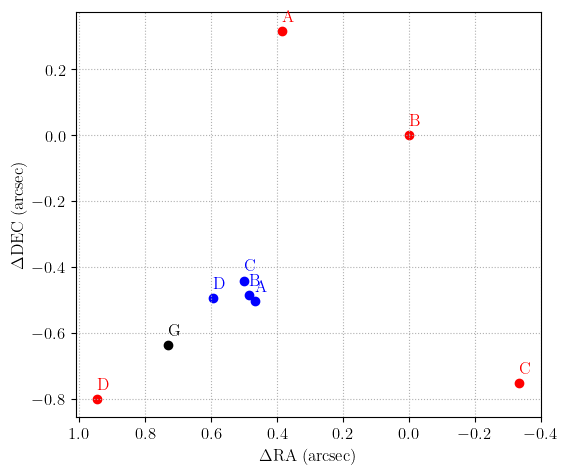

In [7]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');


## Fit with floating lens parameters, fixed shear

5 free parameters: theta_E, e1, e2, theta_lens (2)

In [8]:
lensEquationSolver = LensEquationSolver(lens_model) # initialize class for lens equation solver
solver4Point = Solver4Point(lensModel=lens_model, solver_type='PROFILE') # initialize class for 4-image lens model solver, fixed shear
kwargs_lens_init = copy.deepcopy(kwargs_lens) # take as initial guess the Cosmograil solution
print('kwargs_lens_init: \n', kwargs_lens_init)

kwargs_lens_init: 
 [{'theta_E': 0.771, 'e1': np.float64(0.11352899513903074), 'e2': np.float64(-0.255951493964622), 'center_x': np.float64(0.7321), 'center_y': np.float64(-0.639)}, {'gamma1': np.float64(-0.044741106008917134), 'gamma2': np.float64(0.1681494378019113)}]


In [9]:
# solve for lens model parameters that satisfy the 4-image constraints
kwargs_lens_fit, precision = solver4Point.constraint_lensmodel(x_pos=theta[:,0], y_pos=theta[:,1], 
                                                               kwargs_list=kwargs_lens_init, xtol=1e-12)
print('kwargs_lens_fit: \n', kwargs_lens_fit)

kwargs_lens_fit: 
 [{'theta_E': np.float64(0.7762178106689474), 'e1': np.float64(0.06505873283452414), 'e2': np.float64(-0.14679202002089548), 'center_x': np.float64(0.7278955572569784), 'center_y': np.float64(-0.6502509786184708)}, {'gamma1': np.float64(-0.044741106008917134), 'gamma2': np.float64(0.1681494378019113)}]


/opt/miniconda3/envs/quaDM/lib/python3.14/site-packages/lenstronomy/LensModel/Solver/solver4point.py:116: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x = scipy.optimize.fsolve(


In [10]:
theta_lens_fit = np.asarray([kwargs_lens_fit[0]['center_x'],kwargs_lens_fit[0]['center_y']]) # best-fit lens galaxy location
beta_new = np.transpose(lens_model.ray_shooting(theta[:4,0], theta[:4,1], kwargs_lens_fit)) # best-fit source plane coordinates of images
beta_fit = np.mean(beta_new,axis=0) # best-fit source plane coordinate of quasar
print('theta_lens_fit: \n', theta_lens_fit)
print('beta_new: \n', beta_new)
print('beta_fit: \n', beta_fit)

theta_lens_fit: 
 [ 0.72789556 -0.65025098]
beta_new: 
 [[ 0.52668937 -0.50720561]
 [ 0.52672617 -0.50732852]
 [ 0.52687932 -0.50736287]
 [ 0.52673055 -0.50713953]]
beta_fit: 
 [ 0.52675635 -0.50725913]


In [11]:
# solve for the new image positions (which should come very close to the true ones)
lens_equation_solver_fit = LensEquationSolver(lensModel=lens_model)
# theta_img_fit: image positions implied by the best-fit model (NB distinct from the
# stellar fitting radius theta_fit of Sec. III C)
theta_img_fit = np.transpose(lens_equation_solver_fit.image_position_from_source(kwargs_lens=kwargs_lens_fit, 
                                                                             sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1], 
                                                                             min_distance=0.001, search_window=5, 
                                                                             precision_limit=1e-10, num_iter_max=200))

# sort best-fit image positions to their closest true image position
distances = np.zeros((len(theta_img_fit),len(theta)))
for i, point_fit in enumerate(theta_img_fit):
    for j, point in enumerate(theta):
        distances[i,j] = np.linalg.norm(point_fit-point) # euclidean distance between the true and best-fit image positions
closest_indices = np.argmin(distances, axis=1)
theta_img_fit = theta_img_fit[np.argsort(closest_indices)] # Sort theta_img_fit based on the index of the closest point in theta

# print('distances: \n', distances) # distances between true and best-fit image positions
# print(closest_indices)
print('theta: \n', theta) # true image positions
print('theta_img_fit: \n', theta_img_fit) # image positions given best-fit lens model and source location

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_img_fit: 
 [[ 3.86248976e-01  3.16955766e-01]
 [-4.94161967e-04 -5.47273756e-04]
 [-3.36078240e-01 -7.51178263e-01]
 [ 9.47080931e-01 -8.01217258e-01]]


In [12]:
mag = lens_model.magnification(theta[:,0], theta[:,1], kwargs_lens_fit) # magnification of true image positions given best-fit lens model
mag_fit = lens_model.magnification(theta_img_fit[:,0], theta_img_fit[:,1], kwargs_lens_fit) # magnification of best-fit image positions given best-fit lens model
print('mag: \n', mag) 
print('mag_fit: \n', mag_fit) 

mag: 
 [ 6.85554562 -8.69645497  4.41322612 -0.32755596]
mag_fit: 
 [ 6.85065301 -8.68584333  4.41662961 -0.32768001]


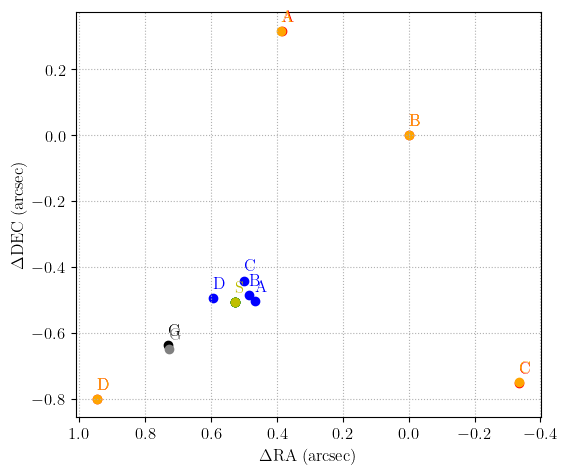

In [13]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')
    ax.scatter(beta_new[i,0],beta_new[i,1],color='g',label=labels[i])
    #ax.text(beta_new[i,0],beta_new[i,1]+0.02,labels[i],color='g',ha='left',va='bottom')

ax.scatter(beta_fit[0],beta_fit[1],color='y')
ax.text(beta_fit[0],beta_fit[1]+0.02,'S',color='y',ha='left',va='bottom')
for i in range(len(theta_img_fit)):
    ax.scatter(theta_img_fit[i,0],theta_img_fit[i,1],color='orange',label=labels[i])
    ax.text(theta_img_fit[i,0],theta_img_fit[i,1]+0.02,labels[i],color='orange',ha='left',va='bottom')

ax.scatter(theta_lens_fit[0],theta_lens_fit[1],color='gray')
ax.text(theta_lens_fit[0],theta_lens_fit[1]+0.02,'G',color='gray',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');

## Fit with floating lens parameters and shear

7 free parameters: theta_E, e1, e2, theta_lens (2), gamma1, gamma2

In [14]:
lensEquationSolver = LensEquationSolver(lens_model) # initialize class for lens equation solver
solver4Point = Solver4Point(lensModel=lens_model, solver_type='PROFILE_SHEAR') # initialize class for 4-image lens model solver, fixed shear
kwargs_lens_init = copy.deepcopy(kwargs_lens_fit) # take as initial guess the previous fit
print('kwargs_lens_init: \n', kwargs_lens_init)

kwargs_lens_init: 
 [{'theta_E': np.float64(0.7762178106689474), 'e1': np.float64(0.06505873283452414), 'e2': np.float64(-0.14679202002089548), 'center_x': np.float64(0.7278955572569784), 'center_y': np.float64(-0.6502509786184708)}, {'gamma1': np.float64(-0.044741106008917134), 'gamma2': np.float64(0.1681494378019113)}]


In [15]:
# solve for lens model parameters that satisfy the 4-image constraints
kwargs_lens_fit, precision = solver4Point.constraint_lensmodel(x_pos=theta[:,0], y_pos=theta[:,1], 
                                                               kwargs_list=kwargs_lens_init, xtol=1e-14)
print('kwargs_lens_fit: \n', kwargs_lens_fit)

kwargs_lens_fit: 
 [{'theta_E': np.float64(0.7761938936468248), 'e1': np.float64(0.06470746299724066), 'e2': np.float64(-0.14701338954709842), 'center_x': np.float64(0.7279119221696829), 'center_y': np.float64(-0.6503046841699275)}, {'gamma1': np.float64(-0.04504194451334216), 'gamma2': np.float64(0.1680691025574214)}]


/opt/miniconda3/envs/quaDM/lib/python3.14/site-packages/lenstronomy/LensModel/Solver/solver4point.py:116: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  x = scipy.optimize.fsolve(


In [16]:
theta_lens_fit = np.asarray([kwargs_lens_fit[0]['center_x'],kwargs_lens_fit[0]['center_y']]) # best-fit lens galaxy location
beta_new = np.transpose(lens_model.ray_shooting(theta[:4,0], theta[:4,1], kwargs_lens_fit)) # best-fit source plane coordinates of images
beta_fit = np.mean(beta_new,axis=0) # best-fit source plane coordinate of quasar
print('theta_lens_fit: \n', theta_lens_fit)
print('beta_new: \n', beta_new)
print('beta_fit: \n', beta_fit)

theta_lens_fit: 
 [ 0.72791192 -0.65030468]
beta_new: 
 [[ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]]
beta_fit: 
 [ 0.52679096 -0.50714071]


In [17]:
# solve for the new image positions (which should come very close to the true ones)
lens_equation_solver_fit = LensEquationSolver(lensModel=lens_model)
# theta_img_fit: image positions implied by the best-fit model (NB distinct from the
# stellar fitting radius theta_fit of Sec. III C)
theta_img_fit = np.transpose(lens_equation_solver_fit.image_position_from_source(kwargs_lens=kwargs_lens_fit, 
                                                                             sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1], 
                                                                             min_distance=0.001, search_window=5, 
                                                                             precision_limit=1e-10, num_iter_max=200))

# sort best-fit image positions to their closest true image position
distances = np.zeros((len(theta_img_fit),len(theta)))
for i, point_fit in enumerate(theta_img_fit):
    for j, point in enumerate(theta):
        distances[i,j] = np.linalg.norm(point_fit-point) # euclidean distance between the true and best-fit image positions
closest_indices = np.argmin(distances, axis=1)
theta_img_fit = theta_img_fit[np.argsort(closest_indices)] # Sort theta_img_fit based on the index of the closest point in theta

# print('distances: \n', distances) # distances between true and best-fit image positions
# print(closest_indices)
print('theta: \n', theta) # true image positions
print('theta_img_fit: \n', theta_img_fit) # image positions given best-fit lens model and source location

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_img_fit: 
 [[ 3.86000000e-01  3.16900000e-01]
 [ 1.34293889e-12  1.80715387e-12]
 [-3.36000000e-01 -7.51600000e-01]
 [ 9.47000000e-01 -8.01200000e-01]]


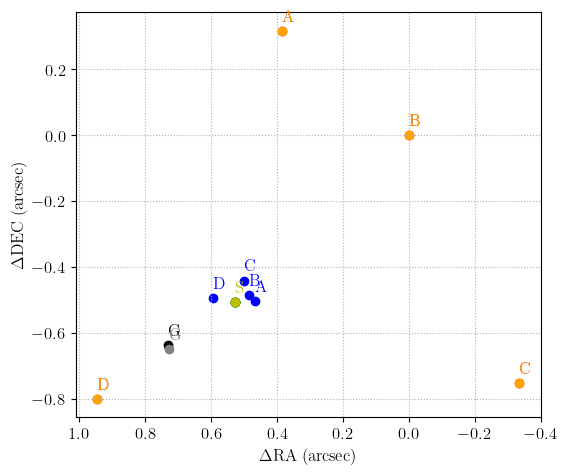

In [18]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')
    ax.scatter(beta_new[i,0],beta_new[i,1],color='g',label=labels[i])
    #ax.text(beta_new[i,0],beta_new[i,1]+0.02,labels[i],color='g',ha='left',va='bottom')

ax.scatter(beta_fit[0],beta_fit[1],color='y')
ax.text(beta_fit[0],beta_fit[1]+0.02,'S',color='y',ha='left',va='bottom')
for i in range(len(theta_img_fit)):
    ax.scatter(theta_img_fit[i,0],theta_img_fit[i,1],color='orange',label=labels[i])
    ax.text(theta_img_fit[i,0],theta_img_fit[i,1]+0.02,labels[i],color='orange',ha='left',va='bottom')

ax.scatter(theta_lens_fit[0],theta_lens_fit[1],color='gray')
ax.text(theta_lens_fit[0],theta_lens_fit[1]+0.02,'G',color='gray',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');

In [19]:
psi_fit = lens_model.potential(theta[:,0], theta[:,1], kwargs_lens_fit)  # lensing potential at image positions (in arcsec^2)
alpha_fit = np.transpose(lens_model.alpha(theta[:,0], theta[:,1], kwargs_lens_fit)) # deflection angles at image positions (in arcsec)
npt.assert_almost_equal(theta_img_fit - alpha_fit, beta_new, decimal=10) # check that the lens equation is satisfied at the best-fit image positions
print('psi_fit: \n', psi_fit)
print('alpha_fit: \n', alpha_fit)

psi_fit: 
 [0.80033236 0.7132534  0.8678773  0.06059264]
alpha_fit: 
 [[-0.14079096  0.82404071]
 [-0.52679096  0.50714071]
 [-0.86279096 -0.24445929]
 [ 0.42020904 -0.29405929]]


## Distortions and magnification

The change in the deflection field distorts extended images and magnifies unresolved small
sources.

The lensing Jacobian $J$ is the differential of the lens equation. For the macro model
alone the source position is $\beta = \varphi(\theta)$, so the paper's
$J_{ij} \equiv \partial\varphi_i/\partial\theta_j$ is

$$ J_{ij} \equiv {\frac {\partial \varphi _{i}}{\partial \theta _{j}}}=\delta _{ij}-{\frac {\partial \alpha _{i}}{\partial \theta _{j}}}=\delta _{ij}-{\frac {\partial ^{2}\psi }{\partial \theta _{i}\partial \theta _{j}}}
=\left[{\begin{array}{c c }1-\kappa -\gamma _{1}&-\gamma _{2}\\-\gamma _{2}&1-\kappa +\gamma _{1}\end{array}}\right],
$$

with $\delta_{ij}$ the Kronecker delta and the derivatives

$$
\kappa \equiv{\partial \psi  \over 2\partial \theta _{1}\partial \theta _{1}}+{\partial \psi  \over 2\partial \theta _{2}\partial \theta _{2}},~\gamma _{1}\equiv {\partial \psi  \over 2\partial \theta _{1}\partial \theta _{1}}-{\partial \psi  \over 2\partial \theta _{2}\partial \theta _{2}},~\gamma _{2}\equiv {\partial \psi  \over \partial \theta _{1}\partial \theta _{2}}.
$$

(The off-diagonal sign follows the code below, where `jacobian_fit` $= \mathbb{1} -$ `hessian_fit`
and $\gamma_2 =$ `hessian_fit[0,1]`; it matches App. Macrolensing Models of the paper.)
Convergence defined this way is a property of the deflection field, which for a single
deflector plane coincides with the surface mass density in units of $\Sigma_\mathrm{cr}$.

$\det J$ maps an infinitesimal area element from the image plane to the source
plane. Lensing preserves surface brightness, so it is this change in area that magnifies:
the signed magnification is

$$ A^\mathrm{I} \equiv \frac{F_{\rm lensed}}{F_{\rm unlensed}} = 1/\det\big(J^\mathrm{I}\big)={1 \over (1-\kappa )^{2}-\gamma _{1}^{2}-\gamma _{2}^{2}} = \det B^\mathrm{I}.
$$

**Notation.** The paper reserves $A^\mathrm{I}$ for this *magnification* (`mag_fit` in the
code) and never for the Jacobian, which is $J^\mathrm{I}$ (`jacobian_fit`); $\mu$ is
likewise reserved for the proper motion of Eq. (mu), not the magnification. A negative
$A^\mathrm{I}$ means the image has flipped parity relative to the source. The inverse
Jacobian $B^\mathrm{I} = \big(J^\mathrm{I}\big)^{-1}$ (`inv_jacobian_fit`) is what the
astrometric forecasts need: it magnifies both the substructure deflections and the image
proper motion, $\widetilde{\mu}^\mathrm{I} = B^\mathrm{I}\mu$.


In [20]:
mag_fit = lens_model.magnification(theta[:,0], theta[:,1], kwargs_lens_fit) # magnification of true image positions given best-fit lens model
mag_fit_2 = lens_model.magnification(theta_img_fit[:,0], theta_img_fit[:,1], kwargs_lens_fit) # magnification of best-fit image positions given best-fit lens model
flux_ratios_fit = np.abs(mag_fit[:]/mag_fit[0]) # flux ratios of best-fit image positions (relative to image A)
print('mag_fit: \n', mag_fit) 
print('mag_fit_2: \n', mag_fit_2) 
print('flux_ratios: \n', flux_ratios)
print('flux_ratios_fit: \n', flux_ratios_fit)

mag_fit: 
 [ 6.85811488 -8.6880026   4.41145652 -0.32744676]
mag_fit_2: 
 [ 6.85792117 -8.68796867  4.41142154 -0.32744646]
flux_ratios: 
 [1.    1.116 0.59  0.032]
flux_ratios_fit: 
 [1.         1.2668208  0.64324623 0.04774588]


In [21]:
hessian_fit = np.reshape(np.transpose(lens_model.hessian(theta[:,0], theta[:,1], kwargs_lens_fit)), # Hessian; second derivative of the potential
                         (len(theta),2,2))  # reshape to (n_points,2,2)
kappa_fit = lens_model.kappa(theta[:,0], theta[:,1], kwargs_lens_fit)  # convergence
gamma1_fit, gamma2_fit = lens_model.gamma(theta[:,0], theta[:,1], kwargs_lens_fit) # shear components
jacobian_fit = np.asarray(len(theta) * [[[1,0],[0,1]]]) - hessian_fit # Jacobian of the lens mapping
inv_jacobian_fit = np.linalg.inv(jacobian_fit) # inverse of the Jacobian


# check whether the definitions are correct
npt.assert_almost_equal(kappa_fit, 1/2. * (hessian_fit[:,0,0] + hessian_fit[:,1,1]), decimal=8) # check that the convergence is the trace of the Hessian
npt.assert_almost_equal(gamma1_fit, 1/2. * (hessian_fit[:,0,0] - hessian_fit[:,1,1]), decimal=8) # check that the first shear component is the difference of the diagonal elements of the Hessian
npt.assert_almost_equal(gamma2_fit, hessian_fit[:,0,1], decimal=8) # check that the second shear component is the off-diagonal element of the Hessian
npt.assert_almost_equal(mag_fit, 1/((1-kappa_fit)**2 - gamma1_fit**2 - gamma2_fit**2), decimal=8) # check that the magnification is the inverse of the determinant of the Jacobian
npt.assert_almost_equal(mag_fit, np.linalg.det(inv_jacobian_fit), decimal=8) # check that the magnification is the inverse of the determinant of the Jacobian

#print('hessian_fit: \n', hessian_fit)
print('jacobian_fit: \n', jacobian_fit)
print('inv_jacobian_fit: \n', inv_jacobian_fit)
print('kappa_fit: \n', kappa_fit)
# print('gamma1_fit: \n', gamma1_fit)
# print('gamma2_fit: \n', gamma2_fit)

jacobian_fit: 
 [[[ 0.36094529 -0.40990066]
  [-0.40990066  0.86947031]]

 [[ 0.63421023 -0.62792742]
  [-0.62792742  0.44021931]]

 [[ 1.03844882 -0.09882797]
  [-0.09882797  0.22769487]]

 [[-0.05853027 -1.77036808]
  [-1.77036808 -1.37145294]]]
inv_jacobian_fit: 
 [[[ 5.96292726  2.81114583]
  [ 2.81114583  2.47540429]]

 [[-3.82462655 -5.45543508]
  [-5.45543508 -5.51002015]]

 [[ 1.00446602  0.43597531]
  [ 0.43597531  4.58107181]]

 [[ 0.44907782 -0.57970128]
  [-0.57970128  0.01916555]]]
kappa_fit: 
 [0.3847922  0.46278523 0.36692815 1.7149916 ]


In [22]:
eig_fit = np.linalg.eig(inv_jacobian_fit)
eigvals_fit = eig_fit[0]
eigvecs_fit = eig_fit[1]
print('eigvals_fit: \n', eigvals_fit)
print('eigvecs_fit: \n', eigvecs_fit)

eigvals_fit: 
 [[  7.52722337   0.91110819]
 [  0.85281341 -10.18746011]
 [  0.95208923   4.6334486 ]
 [  0.85239324  -0.38414988]]
eigvecs_fit: 
 [[[ 0.87382077 -0.48624814]
  [ 0.48624814  0.87382077]]

 [[ 0.75916358  0.65089988]
  [-0.65089988  0.75916358]]

 [[-0.99286073 -0.11927937]
  [ 0.11927937 -0.99286073]]

 [[ 0.82087535  0.57110739]
  [-0.57110739  0.82087535]]]


# Light distribution

In [23]:
kappa_star = kappa_DV(
    theta_img_fit[:,0]-theta_lens_fit[0],
    theta_img_fit[:,1]-theta_lens_fit[1],
    ell_star,theta_eff_star,PA_major_star,M_Sal,d_lens,d_source,d_lens_source)
print('kappa_star: \n', kappa_star)

kappa_star: 
 [0.04897914 0.09446309 0.04714668 1.20149293]


# Plot

## Summary plot

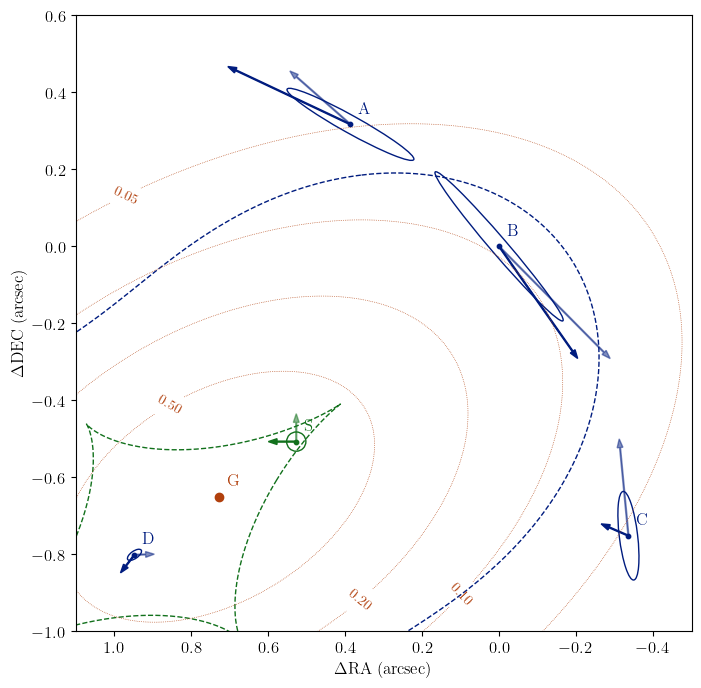

In [24]:
scale = 0.05
xlim = -0.5,1.1
ylim = -1.0,0.6
fig,ax = plt.subplots(1,1,figsize=(8,8))
colors = sns.color_palette("dark")

# critical curve (image plane, blue) and caustic (source plane, green).
# We draw them by hand from LensModelExtensions rather than through
# lenstronomy's lens_model_plot: the latter's kwargs_caustics forces a single
# color on both curves, and here we want them distinguishable.
lens_model_ext = LensModelExtensions(lensModel=lens_model)
ra_crit, dec_crit, ra_caus, dec_caus = lens_model_ext.critical_curve_caustics(
    kwargs_lens_fit, compute_window=5, grid_scale=0.01)
for rc, dc in zip(ra_crit, dec_crit):
    ax.plot(rc, dc, color=colors[0], lw=1, ls='dashed')      # critical curve
for rc, dc in zip(ra_caus, dec_caus):
    ax.plot(rc, dc, color=colors[2], lw=1, ls='dashed')      # caustic

ax.scatter(beta_fit[0],beta_fit[1],s=10,color=colors[2])
ax.arrow(beta_fit[0],beta_fit[1],scale,0,width=0.05*scale,head_width=0.3*scale,color=colors[2],alpha=1)
ax.arrow(beta_fit[0],beta_fit[1],0,scale,width=0.05*scale,head_width=0.3*scale,color=colors[2],alpha=0.5)
el_G = Ellipse((beta_fit[0],beta_fit[1]),scale,scale,fill=False,edgecolor=colors[2],lw=1)
ax.add_patch(el_G)
ax.text(beta_fit[0]-0.02,beta_fit[1]+0.02,'S',color=colors[2],ha='left',va='bottom')

for i in range(len(theta_img_fit)):
    ax.scatter(theta_img_fit[i,0],theta_img_fit[i,1],s=10,color=colors[0],label=labels[i])
    ax.arrow(theta_img_fit[i,0],theta_img_fit[i,1],scale*inv_jacobian_fit[i,0,0],scale*inv_jacobian_fit[i,1,0],width=0.05*scale,head_width=0.3*scale,color=colors[0],alpha=1)
    ax.arrow(theta_img_fit[i,0],theta_img_fit[i,1],scale*inv_jacobian_fit[i,0,1],scale*inv_jacobian_fit[i,1,1],width=0.05*scale,head_width=0.3*scale,color=colors[0],alpha=0.5)
    el = Ellipse((theta_img_fit[i,0],theta_img_fit[i,1]),scale*eigvals_fit[i,0],scale*eigvals_fit[i,1],
                 angle=np.degrees(np.arctan2(eigvecs_fit[i,1,0],eigvecs_fit[i,0,0])),
                 fill=False,edgecolor=colors[0],lw=1)
    ax.add_patch(el)
    ax.text(theta_img_fit[i,0]-0.02,theta_img_fit[i,1]+0.02,labels[i],color=colors[0],ha='left',va='bottom')

ax.scatter(theta_lens_fit[0],theta_lens_fit[1],color=colors[1])
ax.text(theta_lens_fit[0]-0.02,theta_lens_fit[1]+0.02,'G',color=colors[1],ha='left',va='bottom')

# cs = ax.contour(x_grid,y_grid,arr_kappa_star,levels=[1e-2,2e-2,5e-2,1e-1],colors='k',linestyles='dashed',linewidths=0.5)
# ax.clabel(cs, cs.levels, inline=True, fontsize=10)


ax.set_xlim(xlim)
ax.set_ylim(ylim)

xy = np.meshgrid(np.linspace(xlim[0],xlim[1],100),np.linspace(ylim[0],ylim[1],100),indexing='ij')
arr_kappa_star = kappa_DV(
    xy[0]-theta_lens_fit[0],
    xy[1]-theta_lens_fit[1],
    ell_star,theta_eff_star,PA_major_star,M_Sal,d_lens,d_source,d_lens_source)
cs = ax.contour(xy[0],xy[1],arr_kappa_star,levels=[5e-2,1e-1,2e-1,5e-1],colors=colors[1],linestyles='dotted',linewidths=0.5)
ax.clabel(cs, cs.levels, inline=True, fontsize=10)

ax.invert_xaxis()
ax.set_aspect('equal')
#ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');
fig.savefig('../figs/macrolens-B1422.pdf', bbox_inches='tight')

# Save Results

In [25]:
filename = 'macro_lens_results.npz'
np.savez(filename, 
         kappa_fit=kappa_fit, 
         gamma1_fit=gamma1_fit, 
         gamma2_fit=gamma2_fit, 
         mag_fit=mag_fit, 
         hessian_fit=hessian_fit, 
         jacobian_fit=jacobian_fit, 
         inv_jacobian_fit=inv_jacobian_fit, 
         eigvals_fit=eigvals_fit, 
         eigvecs_fit=eigvecs_fit)

## Table `tab:macro` (App. B1422+231 of the paper)

Best-fit macrolensing quantities: image positions $(\theta_x,\theta_y)$ in arcsec
(image B at the origin), convergence $\kappa$, shear $(\gamma_1,\gamma_2)$, signed
magnification $A$, and smooth stellar convergence $\kappa_*$.

In [26]:
# LaTeX rows of Table tab:macro, straight from the fit above.
print(r'I & $\theta_x$ & $\theta_y$ & $\kappa$ & $\gamma_1$ & $\gamma_2$ & $A$ & $\kappa_*$ \\')
print(r'\hline')
for i in range(len(labels)):
    print(r'%s & $%.3f$ & $%.3f$ & $%.3f$ & $%.3f$ & $%.3f$ & $%+.2g$ & $%.3g$ \\'
          % (labels[i], theta[i, 0], theta[i, 1], kappa_fit[i],
             gamma1_fit[i], gamma2_fit[i], mag_fit[i], kappa_star[i]))

print('\npredicted flux ratios A:B:C:D = ' +
      ':'.join('%.2f' % r for r in np.abs(mag_fit/mag_fit[0])))
print('observed  flux ratios A:B:C:D = ' + ':'.join('%.2f' % r for r in flux_ratios))

I & $\theta_x$ & $\theta_y$ & $\kappa$ & $\gamma_1$ & $\gamma_2$ & $A$ & $\kappa_*$ \\
\hline
A & $0.386$ & $0.317$ & $0.385$ & $0.254$ & $0.410$ & $+6.9$ & $0.049$ \\
B & $0.000$ & $0.000$ & $0.463$ & $-0.097$ & $0.628$ & $-8.7$ & $0.0945$ \\
C & $-0.336$ & $-0.752$ & $0.367$ & $-0.405$ & $0.099$ & $+4.4$ & $0.0471$ \\
D & $0.947$ & $-0.801$ & $1.715$ & $-0.656$ & $1.770$ & $-0.33$ & $1.2$ \\

predicted flux ratios A:B:C:D = 1.00:1.27:0.64:0.05
observed  flux ratios A:B:C:D = 1.00:1.12:0.59:0.03


# Part II --- Cluster lens: SDSS J1029+2623

The direct analogue of Part I for the cluster lens. Three images of a quasar at
$z_\mathrm{S} = 2.1992$ behind a cluster at $z_\mathrm{L} = 0.588$, separated by
$22.5''$ ($\sim150$ kpc projected at the lens), sitting $\sim90$--$100$ kpc from
the cluster center.

No lens model is fit here: the convergence and shear at the three images come
from the cluster-scale reconstruction of Acebron+2022, evaluated at the quasar
redshift, and are tabulated in `params_J1029_2623.py`. The same $B^\mathrm{I}$
convention as Part I is applied there, so the two systems feed `sensitivity.ipynb`
through an identical interface.

The star-import below rebinds the system-level names (`d_lens`, `z_lens`,
`kappa_fit`, `inv_jacobian_fit`, `labels`, `kappa_star`, ...) from B1422+231 to
SDSS J1029+2623; re-running any Part I cell afterwards requires re-running Part I
from the top.

In [27]:
# NOTE: rebinds the system-level names from the galaxy lens to the cluster lens.
from params_J1029_2623 import *

print('SDSS J1029+2623:  z_L = %.3f,  z_S = %.4f' % (z_lens, z_source))
print('D_L = %.2f Gpc,  D_S = %.2f Gpc,  D_LS = %.2f Gpc'
      % (d_lens/Gpc, d_source/Gpc, d_lens_source/Gpc))
print('transverse scale at the lens = %.1f kpc/arcsec' % (length_per_arcsec/kpc))
print('Sigma_crit = %.2g M_sun/pc^2' % (Sigma_crit_val/(M_Solar/pc**2)))
for j in [1, 2]:
    sep = np.linalg.norm(theta[j]-theta[0])
    print('A--%s separation = %.1f arcsec = %.0f kpc projected'
          % (labels[j], sep, sep*length_per_arcsec/kpc))
print('B--C separation  = %.2f arcsec' % np.linalg.norm(theta[2]-theta[1]))
print('tangential stretch |B|_max per image =', np.round(np.max(np.abs(eigvals_fit), axis=1), 1))

# ---- Table tab:macro-cluster (App. SDSS J1029+2623 of the paper) ----
print()
print(r'I & $\theta_x$ & $\theta_y$ & $\kappa$ & $\gamma_1$ & $\gamma_2$ & $A$ & $\kappa_*$ \\')
print(r'\hline')
for i in range(len(labels)):
    print(r'%s & $%.2f$ & $%.2f$ & $%.3f$ & $%.3f$ & $%.3f$ & $%+.3g$ & $%.3f$ \\'
          % (labels[i], theta[i, 0], theta[i, 1], kappa_fit[i],
             gamma1_fit[i], gamma2_fit[i], mag_fit[i], kappa_star))

SDSS J1029+2623:  z_L = 0.588,  z_S = 2.1992
D_L = 1.37 Gpc,  D_S = 1.71 Gpc,  D_LS = 1.03 Gpc
transverse scale at the lens = 6.6 kpc/arcsec
Sigma_crit = 2e+03 M_sun/pc^2
A--B separation = 22.5 arcsec = 149 kpc projected
A--C separation = 21.0 arcsec = 139 kpc projected
B--C separation  = 1.86 arcsec
tangential stretch |B|_max per image = [ 5.4 22.5 22.6]

I & $\theta_x$ & $\theta_y$ & $\kappa$ & $\gamma_1$ & $\gamma_2$ & $A$ & $\kappa_*$ \\
\hline
A & $0.00$ & $0.00$ & $0.499$ & $0.070$ & $-0.308$ & $+6.63$ & $0.003$ \\
B & $4.05$ & $22.18$ & $0.459$ & $-0.332$ & $0.369$ & $+21.6$ & $0.003$ \\
C & $4.76$ & $20.45$ & $0.505$ & $-0.441$ & $0.310$ & $-21.9$ & $0.003$ \\
